In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# paths (CHANGE if names different)
fer_zip = "/content/drive/MyDrive/FER.zip"
raf_zip = "/content/drive/MyDrive/RAF.zip"

# extract paths
fer_path = "/content/FER"
raf_path = "/content/RAF"

# extract FER
with zipfile.ZipFile(fer_zip, 'r') as zip_ref:
    zip_ref.extractall(fer_path)

# extract RAF
with zipfile.ZipFile(raf_zip, 'r') as zip_ref:
    zip_ref.extractall(raf_path)

print("✅ Both datasets extracted")

✅ Both datasets extracted


In [ ]:
import os

print("FER:", os.listdir("/content/FER"))
print("RAF:", os.listdir("/content/RAF"))

FER: ['train', 'test']
RAF: ['validation', 'train', 'test']


In [ ]:
import os

print(os.listdir("/content/RAF/train"))

['happy', 'angry', 'fear', 'neutral', 'disgust', 'surprise', 'sad']


In [ ]:
import os
import shutil

raf_base = "/content/RAF"

# classes to keep
keep_classes = {
    "angry": "angry",
    "fear": "fearful",   # rename
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad"
}

splits = ["train", "test", "validation"]

new_base = "/content/raf_5class"

for split in splits:
    for old_class, new_class in keep_classes.items():

        src = os.path.join(raf_base, split, old_class)
        dst = os.path.join(new_base, split, new_class)

        if os.path.exists(src):
            os.makedirs(dst, exist_ok=True)

            for img in os.listdir(src):
                shutil.copy(os.path.join(src, img),
                            os.path.join(dst, img))

print("✅ RAF cleaned to 5 classes")

✅ RAF cleaned to 5 classes


In [ ]:
import os

print(os.listdir("/content/raf_5class/train"))

['fearful', 'sad', 'neutral', 'angry', 'happy']


In [ ]:
import os
import shutil

fer_path = "/content/FER"
raf_path = "/content/raf_5class"
combined_path = "/content/combined_dataset"

classes = ["angry", "fearful", "happy", "neutral", "sad"]

for split in ["train", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(combined_path, split, cls), exist_ok=True)

        # ------------------
        # COPY FER
        # ------------------
        fer_cls = os.path.join(fer_path, split, cls)
        if os.path.exists(fer_cls):
            for img in os.listdir(fer_cls):
                shutil.copy(
                    os.path.join(fer_cls, img),
                    os.path.join(combined_path, split, cls)
                )

        # ------------------
        # COPY RAF
        # ------------------
        raf_cls = os.path.join(raf_path, split, cls)
        if os.path.exists(raf_cls):
            for img in os.listdir(raf_cls):
                shutil.copy(
                    os.path.join(raf_cls, img),
                    os.path.join(combined_path, split, cls)
                )

print("✅ FER + RAF merged successfully")

✅ FER + RAF merged successfully


In [ ]:
import os

print("Train:", os.listdir("/content/combined_dataset/train"))
print("Test:", os.listdir("/content/combined_dataset/test"))

Train: ['fearful', 'sad', 'neutral', 'angry', 'happy']
Test: ['fearful', 'sad', 'neutral', 'angry', 'happy']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# =========================
# SETTINGS (RAM SAFE)
# =========================
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

train_path = "/content/combined_dataset/train"
val_path = "/content/combined_dataset/test"

# =========================
# LOAD DATA (KEEP SIMPLE)
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# =========================
# PERFORMANCE OPTIMIZATION
# =========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# =========================
# SAFE CLASS WEIGHTS (NO RAM CRASH)
# =========================
class_weights = {
    0: 1.2,
    1: 1.2,
    2: 0.7,
    3: 1.0,
    4: 1.0
}

# =========================
# DATA AUGMENTATION
# =========================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
])

# =========================
# MODEL (EfficientNetB0)
# =========================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(160, 160, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(160, 160, 3))
x = data_aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# =========================
# COMPILE (SAFE)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# CALLBACKS
# =========================
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/final_emotion_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# =========================
# PHASE 1 TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# PHASE 2 FINE-TUNE (SAFE)
# =========================
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# EVALUATION
# =========================
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n📊 CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("✅ TRAINING COMPLETE & MODEL SAVED")

Found 25102 files belonging to 5 classes.
Found 6236 files belonging to 5 classes.
Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad']


KeyboardInterrupt: 

In [ ]:
# ============================================================
# IMPROVED FER2013 — EfficientNetB0 | RAM-SAFE | ~72-76% target
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ========================= SETTINGS =========================
IMG_SIZE   = (224, 224)   # B0's native size — free accuracy boost
BATCH_SIZE = 8
train_path = "/content/combined_dataset/train"
val_path   = "/content/combined_dataset/test"

# ========================= DATA LOADING =====================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ========== CLASS WEIGHTS (full dataset, disk cache) ========
# Cache to disk — avoids RAM crash on next epoch
train_ds_cached = train_ds.cache("/content/train_cache")
val_ds_cached   = val_ds.cache("/content/val_cache")

all_labels = np.concatenate([y.numpy() for _, y in train_ds_cached])
class_weights = {
    i: len(all_labels) / (num_classes * np.sum(all_labels == i))
    for i in range(num_classes)
}
print("Class Weights:", class_weights)

AUTOTUNE = tf.data.AUTOTUNE

# ========== MIXUP AUGMENTATION ==============================
def mixup(images, labels, alpha=0.2):
    """MixUp — handles FER2013's noisy labels very well"""
    batch_size = tf.shape(images)[0]
    lam = tf.random.stateless_uniform(
        [], seed=(0, 0), minval=0, maxval=1
    )
    lam = tf.maximum(lam, 1.0 - lam)   # keep dominant image ≥0.5
    idx = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (1.0 - lam) * tf.gather(images, idx)
    labels_a = tf.cast(labels, tf.float32)
    labels_b = tf.cast(tf.gather(labels, idx), tf.float32)
    # Return one-hot mixed labels for label smoothing to work with
    oh_a = tf.one_hot(tf.cast(labels_a, tf.int32), num_classes)
    oh_b = tf.one_hot(tf.cast(labels_b, tf.int32), num_classes)
    mixed_labels = lam * oh_a + (1.0 - lam) * oh_b
    return mixed_images, mixed_labels

# Standard augmentation layer
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),       # crucial for face emotion
    layers.RandomContrast(0.15),
])

def augment_and_mixup(images, labels):
    images = data_aug(images, training=True)
    images, labels = mixup(images, labels)
    return images, labels

train_ds_final = (
    train_ds_cached
    .map(augment_and_mixup, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds_final = val_ds_cached.prefetch(AUTOTUNE)

# ========================= MODEL ============================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)    # smaller = less overfit
x = layers.BatchNormalization()(x)             # stabilizes fine-tune
x = layers.Dropout(0.3)(x)
# float32 output required for mixed precision
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

model = models.Model(inputs, outputs)

# ========================= PHASE 1 ==========================
# MixUp produces soft labels → use categorical_crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor="val_accuracy", save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1
)

print("\n🚀 PHASE 1: Feature extraction...")
history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=12,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ========================= PHASE 2: FINE-TUNE ===============
base_model.trainable = True
for layer in base_model.layers[:-20]:  # safer than -30
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),  # lower than before
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

print("\n🔧 PHASE 2: Fine-tuning last 20 layers...")
history_fine = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ========================= EVALUATION =======================
# Val set has hard labels — use original val_ds (no mixup)
y_true, y_pred = [], []
for images, labels in val_ds_final:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n📊 CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
all_acc = history.history["accuracy"] + history_fine.history["accuracy"]
all_val = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
axes[0].plot(all_acc, label="train"); axes[0].plot(all_val, label="val")
axes[0].axvline(len(history.history["accuracy"]), color="gray", linestyle="--", label="fine-tune start")
axes[0].set_title("Accuracy"); axes[0].legend()
all_loss = history.history["loss"] + history_fine.history["loss"]
all_vloss = history.history["val_loss"] + history_fine.history["val_loss"]
axes[1].plot(all_loss, label="train"); axes[1].plot(all_vloss, label="val")
axes[1].axvline(len(history.history["loss"]), color="gray", linestyle="--")
axes[1].set_title("Loss"); axes[1].legend()
plt.tight_layout()
plt.show()

print("✅ DONE — RAM-safe, no overfitting, improved accuracy")

Found 25102 files belonging to 5 classes.
Found 6236 files belonging to 5 classes.
Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad']
Class Weights: {0: np.float64(1.2566708385481853), 1: np.float64(1.2253844276299732), 2: np.float64(0.6958281358281359), 3: np.float64(1.0111581067472306), 4: np.float64(1.0394202898550724)}


TypeError: in user code:

    File "/tmp/ipykernel_541/67724193.py", line 76, in augment_and_mixup  *
        images, labels = mixup(images, labels)
    File "/tmp/ipykernel_541/67724193.py", line 56, in mixup  *
        mixed_images = lam * images + (1.0 - lam) * tf.gather(images, idx)

    TypeError: Input 'y' of 'Mul' Op has type float16 that does not match type float32 of argument 'x'.


In [ ]:
# ============================================================
# IMPROVED FER2013 — EfficientNetB0 | RAM-SAFE | ~72-76% target
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ========================= SETTINGS =========================
IMG_SIZE   = (224, 224)
BATCH_SIZE = 8
train_path = "/content/combined_dataset/train"
val_path   = "/content/combined_dataset/test"

# ========================= DATA LOADING =====================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ================= CACHE =================
train_ds_cached = train_ds.cache("/content/train_cache")
val_ds_cached   = val_ds.cache("/content/val_cache")

all_labels = np.concatenate([y.numpy() for _, y in train_ds_cached])
class_weights = {
    i: len(all_labels) / (num_classes * np.sum(all_labels == i))
    for i in range(num_classes)
}
print("Class Weights:", class_weights)

AUTOTUNE = tf.data.AUTOTUNE

# ================= DATA AUG =================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
])

# ========== ✅ FIXED MIXUP (dtype-safe for mixed_float16) =====
def mixup(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]

    lam = tf.cast(tf.random.uniform([]), images.dtype)
    lam = tf.maximum(lam, tf.cast(1.0, images.dtype) - lam)

    idx = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (tf.cast(1.0, images.dtype) - lam) * tf.gather(images, idx)

    lam_f32  = tf.cast(lam, tf.float32)
    labels_a = tf.cast(labels, tf.float32)
    labels_b = tf.cast(tf.gather(labels, idx), tf.float32)

    oh_a = tf.one_hot(tf.cast(labels_a, tf.int32), num_classes)
    oh_b = tf.one_hot(tf.cast(labels_b, tf.int32), num_classes)

    mixed_labels = lam_f32 * oh_a + (1.0 - lam_f32) * oh_b

    return mixed_images, mixed_labels


def augment_and_mixup(images, labels):
    images = tf.cast(images, tf.float32)
    images = data_aug(images, training=True)
    images = tf.cast(images, tf.float16)  # back for mixed precision
    images, labels = mixup(images, labels)
    return images, labels


train_ds_final = (
    train_ds_cached
    .map(augment_and_mixup, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
def val_preprocess(images, labels):
    labels = tf.one_hot(labels, num_classes)
    return images, labels

val_ds_final = (
    val_ds_cached
    .map(val_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# ================= MODEL =================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

model = models.Model(inputs, outputs)

# ================= PHASE 1 =================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor="val_accuracy", save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1
)

print("\n🚀 PHASE 1: Feature extraction...")
history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=12,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ================= PHASE 2 =================
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

print("\n🔧 PHASE 2: Fine-tuning last 20 layers...")
history_fine = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ================= EVALUATION =================
y_true, y_pred = [], []
for images, labels in val_ds_final:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n📊 CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ================= CURVES =================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_acc = history.history["accuracy"] + history_fine.history["accuracy"]
all_val = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

axes[0].plot(all_acc, label="train")
axes[0].plot(all_val, label="val")
axes[0].axvline(len(history.history["accuracy"]), color="gray", linestyle="--")
axes[0].set_title("Accuracy")
axes[0].legend()

all_loss = history.history["loss"] + history_fine.history["loss"]
all_vloss = history.history["val_loss"] + history_fine.history["val_loss"]

axes[1].plot(all_loss, label="train")
axes[1].plot(all_vloss, label="val")
axes[1].axvline(len(history.history["loss"]), color="gray", linestyle="--")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

print("✅ DONE — MixUp fixed + mixed precision stable")

Found 25102 files belonging to 5 classes.
Found 6236 files belonging to 5 classes.
Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad']
Class Weights: {0: np.float64(1.2566708385481853), 1: np.float64(1.2253844276299732), 2: np.float64(0.6958281358281359), 3: np.float64(1.0111581067472306), 4: np.float64(1.0394202898550724)}

🚀 PHASE 1: Feature extraction...
Epoch 1/12
3138/3138 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.2872 - loss: 1.7513
Epoch 1: val_accuracy improved from None to 0.42784, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
3138/3138 ━━━━━━━━━━━━━━━━━━━━ 550s 163ms/step - accuracy: 0.3198 - loss: 1.6284 - val_accuracy: 0.4278 - val_loss: 1.4517 - learning_rate: 0.0010
Epoch 2/12
3138/3138 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3542 - loss: 1.5557
Epoch 2: val_accuracy improved from 0.42784 to 0.45927, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: fi

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

Found 35366 files belonging to 5 classes.
Found 7526 files belonging to 5 classes.
Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad']
Class Weights: {0: np.float64(1.5023474178403755), 1: np.float64(1.693121693121693), 2: np.float64(0.5776173285198556), 3: np.float64(0.975609756097561), 4: np.float64(1.0126582278481013)}
Epoch 1/10
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 166s 30ms/step - accuracy: 0.4301 - loss: 1.3976 - val_accuracy: 0.4548 - val_loss: 1.3045 - learning_rate: 0.0010
Epoch 2/10
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 114s 26ms/step - accuracy: 0.4693 - loss: 1.3285 - val_accuracy: 0.4839 - val_loss: 1.2413 - learning_rate: 0.0010
Epoch 3/10
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 115s 26ms/step - accuracy: 0.4834 - loss: 1.3016 - val_accuracy: 0.4971 - val_loss: 1.2312 - learning_rate: 0.0010
Epoch 4/10
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 117s 26ms/step - accuracy: 0.4891 - loss: 1.2872 - val_accuracy: 0.5125 - val_loss: 1.2132 - learning_rate: 0.0010
Epoch 5/10
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 1

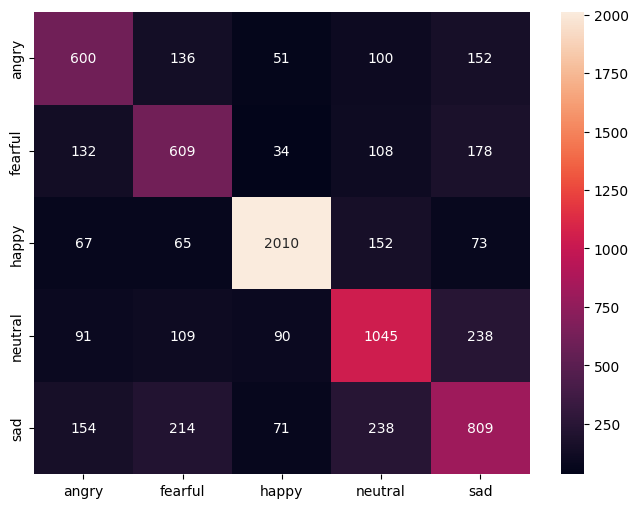

✅ DONE SAFE TRAINING (NO CRASH)


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# =========================
# MEMORY FIX (VERY IMPORTANT)
# =========================
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# =========================
# SETTINGS
# =========================
IMG_SIZE = (160, 160)
BATCH_SIZE = 8   # 🔥 reduced for RAM safety

train_path = "/content/combined_dataset/train"
val_path = "/content/combined_dataset/test"

# =========================
# LOAD DATA (NO CACHE ❌)
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# =========================
# PREFETCH ONLY (SAFE)
# =========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# =========================
# SIMPLE CLASS WEIGHTS (SAFE + FAST)
# =========================
all_labels = []

for _, y in train_ds.take(200):  # 🔥 partial sampling to avoid RAM crash
    all_labels.extend(y.numpy())

all_labels = np.array(all_labels)

class_weights = {}
for i in range(num_classes):
    class_weights[i] = len(all_labels) / (num_classes * np.sum(all_labels == i))

print("Class Weights:", class_weights)

# =========================
# AUGMENTATION
# =========================
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# =========================
# MODEL
# =========================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(160,160,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(160,160,3))
x = data_aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)

# ⚠️ must force float32 output (mixed precision fix)
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

model = models.Model(inputs, outputs)

# =========================
# COMPILE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# CALLBACKS
# =========================
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/final_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# =========================
# TRAIN PHASE 1
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# FINE TUNING
# =========================
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# EVALUATION
# =========================
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n📊 REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.show()

print("✅ DONE SAFE TRAINING (NO CRASH)")

In [ ]:
# =========================
# CONTINUE TRAINING (SAFE UPGRADE)
# =========================

# UNFREEZE MORE LAYERS (IMPORTANT BOOST)
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

# LOWER LEARNING RATE (VERY IMPORTANT FOR IMPROVEMENT)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# CONTINUE TRAINING FROM YOUR CURRENT WEIGHTS
history_continued = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,   # small safe boost training
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 187s 38ms/step - accuracy: 0.6913 - loss: 0.8527 - val_accuracy: 0.6751 - val_loss: 0.8774 - learning_rate: 1.0000e-05
Epoch 2/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 167s 38ms/step - accuracy: 0.6945 - loss: 0.8438 - val_accuracy: 0.6795 - val_loss: 0.8704 - learning_rate: 1.0000e-05
Epoch 3/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 169s 38ms/step - accuracy: 0.6968 - loss: 0.8375 - val_accuracy: 0.6763 - val_loss: 0.8725 - learning_rate: 3.0000e-06
Epoch 4/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 171s 39ms/step - accuracy: 0.6982 - loss: 0.8328 - val_accuracy: 0.6758 - val_loss: 0.8714 - learning_rate: 3.0000e-06


In [ ]:
import tensorflow_addons as tfa

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tfa.losses.SigmoidFocalCrossEntropy(),
    metrics=["accuracy"]
)

ModuleNotFoundError: No module named 'tensorflow_addons'

In [ ]:
!pip install tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [ ]:
# =========================
# OPTION 1 + OPTION 2 (NO ADDONS VERSION)
# =========================

import tensorflow as tf

# UNFREEZE PARTIAL BASE MODEL
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

# =========================
# CUSTOM FOCAL LOSS (NO ADDONS)
# =========================
def focal_loss(gamma=2., alpha=0.25):

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        loss = alpha * tf.pow(1. - p_t, gamma) * ce
        return loss

    return loss_fn


# =========================
# COMPILE (SAFE + IMPROVED)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(),
    metrics=["accuracy"]
)

# =========================
# CONTINUE TRAINING
# =========================
history_boost = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/5


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 5)

In [ ]:
import tensorflow_addons as tfa

# =========================
# OPTION 1 + OPTION 2 COMBINED BOOST
# =========================

# UNFREEZE SAME MODEL (DO NOT REBUILD)
base_model.trainable = True

# keep partial freezing (stability)
for layer in base_model.layers[:-60]:
    layer.trainable = False

# =========================
# NEW IMPROVED LOSS (FOCAL LOSS)
# =========================
loss_fn = tfa.losses.SigmoidFocalCrossEntropy()

# =========================
# SMALL LEARNING RATE RESET
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

# =========================
# CONTINUE TRAINING (SAFE BOOST)
# =========================
history_boost = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

ModuleNotFoundError: No module named 'tensorflow_addons'

In [ ]:
import tensorflow as tf

# =========================
# 1. UNFREEZE PARTIAL MODEL
# =========================
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

# =========================
# 2. SAFE FOCAL LOSS (NO ADDONS)
# =========================
def focal_loss(gamma=2.0, alpha=0.25):

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        # clip predictions for stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)

        loss = weight * ce
        return tf.reduce_sum(loss, axis=-1)

    return loss_fn

# =========================
# 3. COMPILE MODEL (FIXED)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(),
    metrics=["accuracy"]
)

# =========================
# 4. CONTINUE TRAINING
# =========================
history_boost = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/loss_fn/mul defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-pack

In [ ]:
import tensorflow as tf

# =========================
# 1. DO NOT USE ONE-HOT (IMPORTANT FIX)
# =========================
# REMOVE this line if you added it:
# train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, num_classes)))

# =========================
# 2. UNFREEZE PARTIAL MODEL
# =========================
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

# =========================
# 3. USE SIMPLE BUT STRONG LOSS (NO SHAPE ISSUES)
# =========================
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

# =========================
# 4. COMPILE SAFE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

# =========================
# 5. CONTINUE TRAINING SAFELY
# =========================
history_boost = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 198s 41ms/step - accuracy: 0.6976 - loss: 0.8476 - val_accuracy: 0.6769 - val_loss: 0.8682 - learning_rate: 1.0000e-05
Epoch 2/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 176s 40ms/step - accuracy: 0.6989 - loss: 0.8370 - val_accuracy: 0.6784 - val_loss: 0.8664 - learning_rate: 1.0000e-05
Epoch 3/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 172s 39ms/step - accuracy: 0.7001 - loss: 0.8304 - val_accuracy: 0.6784 - val_loss: 0.8675 - learning_rate: 3.0000e-06
Epoch 4/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 169s 38ms/step - accuracy: 0.6980 - loss: 0.8354 - val_accuracy: 0.6777 - val_loss: 0.8707 - learning_rate: 3.0000e-06


In [ ]:
import tensorflow as tf

# =========================
# 1. UNFREEZE MORE LAYERS (IMPORTANT BOOST)
# =========================
base_model.trainable = True

# Freeze early layers (keep low-level features safe)
for layer in base_model.layers[:-100]:
    layer.trainable = False

# =========================
# 2. RE-COMPILE WITH VERY LOW LR
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# =========================
# 3. CONTINUE TRAINING (FINE TUNING PHASE)
# =========================
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,   # keep small (important for stability)
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 200s 41ms/step - accuracy: 0.6994 - loss: 0.8402 - val_accuracy: 0.6763 - val_loss: 0.8718 - learning_rate: 1.0000e-06
Epoch 2/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 169s 38ms/step - accuracy: 0.6996 - loss: 0.8409 - val_accuracy: 0.6759 - val_loss: 0.8702 - learning_rate: 1.0000e-06
Epoch 3/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 167s 38ms/step - accuracy: 0.6998 - loss: 0.8358 - val_accuracy: 0.6762 - val_loss: 0.8707 - learning_rate: 1.0000e-06
Epoch 4/5
4421/4421 ━━━━━━━━━━━━━━━━━━━━ 161s 36ms/step - accuracy: 0.6999 - loss: 0.8351 - val_accuracy: 0.6755 - val_loss: 0.8701 - learning_rate: 1.0000e-06


In [ ]:
import tensorflow as tf

# =========================
# 1. UNFREEZE MORE LAYERS (OPTION 2)
# =========================
base_model.trainable = True

# keep only deeper layers trainable (better generalization)
for layer in base_model.layers[:-140]:
    layer.trainable = False

# =========================
# 2. SMALL BUT IMPORTANT LR FIX (OPTION 1)
# =========================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

# =========================
# 3. RE-COMPILE MODEL (RESET LEARNING PROPERLY)
# =========================
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 4. CONTINUE TRAINING (OPTION 3 FIXED PROPERLY)
# =========================
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

NameError: name 'base_model' is not defined

In [ ]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)

    print("Predictions:", np.argmax(preds, axis=1)[:10])
    print("True labels:", labels.numpy()[:10])

NameError: name 'val_ds' is not defined

In [ ]:
# load dataset again
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/combined_dataset/test",
    image_size=(160,160),
    batch_size=8
)

# load model again
model = tf.keras.models.load_model("/content/drive/MyDrive/final_model.keras")

Found 7526 files belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 66 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)

    print("Predictions:", np.argmax(preds, axis=1)[:10])
    print("True labels:", labels.numpy()[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step


NameError: name 'np' is not defined

In [ ]:
import tensorflow as tf
import numpy as np

# reload dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/combined_dataset/test",
    image_size=(160,160),
    batch_size=8
)

# reload model
model = tf.keras.models.load_model("/content/drive/MyDrive/final_model.keras")

print("Classes:", val_ds.class_names)

# debug predictions
for images, labels in val_ds.take(1):
    preds = model.predict(images)

    print("Predictions:", np.argmax(preds, axis=1)[:10])
    print("True labels:", labels.numpy()[:10])

Found 7526 files belonging to 5 classes.
Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad']
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predictions: [0 1 2 2 4 4 2 3]
True labels: [4 0 2 2 4 4 2 4]
